# Масштабирование семантического поиска с FAISS

В предыдущей работе мы построили поиск по документации Python. Теперь проверим,
можно ли ускорить поиск по готовым эмбеддингам с помощью HNSW и IVF, сколько
точности при этом теряется и когда окупается построение индекса.

Во всех основных сравнениях возвращаем **10 чанков**. Отдельно оцениваем
совпадение с точными соседями и релевантность документов. Демонстрационный
ноутбук `faiss_vector_search_demo.ipynb` изучен; здесь используем собственные
данные предыдущего задания и одинаковую реализацию FAISS для точного и ANN-поиска.


In [ ]:
import gc
import hashlib
import json
import math
import os
import platform
import time
from importlib.metadata import version
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from threadpoolctl import threadpool_info, threadpool_limits

## 1. Настройки


In [ ]:
ROOT = Path.cwd()
INPUT = ROOT / "input"
RESULTS = ROOT / "faiss_results"
FIGURES = RESULTS / "figures"
INDEXES = RESULTS / "indexes"
for folder in (RESULTS, FIGURES, INDEXES):
    folder.mkdir(parents=True, exist_ok=True)

In [ ]:
SEED = 42
K = 10
TARGET_RECALL = 0.95
THREADS = 1
BUILD_REPEATS = 3
SEARCH_ROUNDS = 11
WARMUP_ROUNDS = 2
BOOTSTRAP_SAMPLES = 3000
TRAIN_LIMIT = 20_000
MODEL = "BAAI/bge-small-en-v1.5"
QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

np.random.seed(SEED)
thread_limit = threadpool_limits(limits=THREADS)
faiss.omp_set_num_threads(THREADS)

In [ ]:
HNSW_M = 16
EF_CONSTRUCTION = 100
EF_VALUES = [1, 2, 4, 8, 12, 16, 24, 32, 64, 128, 256]
SCALE_EF_VALUES = EF_VALUES + [512, 1024, 2048]
NLIST_VALUES = [4, 8]
NPROBE_VALUES = [1, 2, 4, 8]
M_VALUES = [8, 16, 32]
CONSTRUCTION_VALUES = [40, 100]
REAL_SIZES = [100, 250, 430]
STRESS_SIZES = [2_000, 10_000, 50_000]
NOISE_NORM = 0.20
QUERY_COUNTS = np.array([1, 10, 100, 1_000, 10_000, 100_000])

In [ ]:
pd.set_option("display.max_colwidth", 85)
pd.set_option("display.max_columns", 14)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "grid.alpha": 0.2, "figure.dpi": 110})

Параметры и порог качества заданы до просмотра результатов. Все индексы используют
один поток CPU. Эмбеддинги уже вычислены, поэтому время кодирования текста,
чтения файлов и сетевых запросов в измерения поиска не входит.

Основной критерий выбора — средний ANN Recall@10 не ниже 0,95 **на dev**.
Это не гарантия для каждого запроса. Тестовую часть используем для итоговой проверки.


In [ ]:
environment = {
    "platform": platform.platform(), "architecture": platform.machine(),
    "logical_cpus": os.cpu_count(), "faiss_threads": faiss.omp_get_max_threads(),
    "faiss_compile_options": faiss.get_compile_options(),
    "versions": {name: version(name) for name in
                 ["faiss-cpu", "numpy", "pandas", "matplotlib", "threadpoolctl"]},
    "threadpools": threadpool_info(),
}
display(pd.Series({key: value for key, value in environment.items()
                   if key not in ["versions", "threadpools"]}))
display(pd.Series(environment["versions"], name="version"))

platform                 Linux-6.10.14-linuxkit-aarch64-with-glibc2.35
architecture                                                   aarch64
logical_cpus                                                         8
faiss_threads                                                        1
faiss_compile_options                                   OPTIMIZE NEON 
dtype: object

faiss-cpu        1.12.0
numpy            1.26.4
pandas            2.1.1
matplotlib        3.8.0
threadpoolctl     3.2.0
Name: version, dtype: object

## 2. Данные предыдущего исследования


In [ ]:
manifest = json.loads((INPUT / "manifest.json").read_text())
for filename, info in manifest.items():
    digest = hashlib.sha256((INPUT / filename).read_bytes()).hexdigest()
    assert digest == info["sha256"], f"Изменился входной файл: {filename}"

previous = json.loads((INPUT / "previous_experiment.json").read_text())
corpus = pd.DataFrame(json.loads((INPUT / "corpus.json").read_text())["documents"])
chunks = pd.DataFrame(json.loads((INPUT / "chunks_fixed.json").read_text()))
queries = pd.DataFrame(json.loads((INPUT / "queries.json").read_text()))
qrels = pd.read_csv(INPUT / "qrels.csv")
revisions = json.loads((INPUT / "model_revisions.json").read_text())
assert previous["best_dev"] == ["BGE", "fixed"]

In [ ]:
def original_cache_key(texts):
    payload = {"model": {"repo": MODEL, "prefix": QUERY_PREFIX},
               "revision": revisions["BGE"], "texts": texts,
               "normalization": True,
               "sentence_transformers": previous["versions"]["sentence-transformers"]}
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()

for filename, texts in [
    ("BGE_fixed.npz", chunks["text"].tolist()),
    ("BGE_queries.npz", [QUERY_PREFIX + text for text in queries["query"]]),
]:
    assert original_cache_key(texts)[:16] in manifest[filename]["source"]
print("Порядок текстов, версия модели и хэши кэша совпали с предыдущей работой.")

Порядок текстов, версия модели и хэши кэша совпали с предыдущей работой.


In [ ]:
X = np.ascontiguousarray(np.load(INPUT / "BGE_fixed.npz")["embeddings"], dtype="float32")
Q = np.ascontiguousarray(np.load(INPUT / "BGE_queries.npz")["embeddings"], dtype="float32")
assert X.shape == (len(chunks), Q.shape[1]) and len(Q) == len(queries)
assert np.isfinite(X).all() and np.isfinite(Q).all()
assert np.allclose(np.linalg.norm(X, axis=1), 1, atol=1e-5)
assert np.allclose(np.linalg.norm(Q, axis=1), 1, atol=1e-5)
faiss.normalize_L2(X)
faiss.normalize_L2(Q)
DEV = queries["split"].eq("dev").to_numpy()
TEST = queries["split"].eq("test").to_numpy()
assert not set(queries.loc[DEV, "query_id"]) & set(queries.loc[TEST, "query_id"])
assert chunks["chunk_id"].is_unique and queries["query_id"].is_unique
assert set(qrels["doc_id"]) <= set(corpus["doc_id"])

In [ ]:
data_summary = pd.Series({
    "Документы": len(corpus), "Чанки": len(X), "Размерность": X.shape[1],
    "Dev-запросы": int(DEV.sum()), "Test-запросы": int(TEST.sum()),
    "Релевантные пары": len(qrels),
    "Пары с human_verified=True": int(qrels["human_verified"].astype(str).str.lower().eq("true").sum()),
    "Точные дубликаты векторов": len(X) - len(np.unique(X, axis=0)),
    "Векторы, МиБ": round(X.nbytes / 2**20, 3),
})
display(data_summary)
display(queries.groupby(["split", "difficulty"]).size().unstack(fill_value=0))

Документы                     258.00
Чанки                         430.00
Размерность                   384.00
Dev-запросы                    10.00
Test-запросы                   24.00
Релевантные пары               42.00
Пары с human_verified=True      0.00
Точные дубликаты векторов       0.00
Векторы, МиБ                    0.63
dtype: float64

difficulty,перефразирование,с ограничениями,точный API
split,,,
dev,4,3,3
test,8,9,7


В работе сохранены **258 документов, 430 чанков и 34 запроса** предыдущего этапа.
Размерность — 384, векторы занимают всего **0,63 МиБ**. Точных дубликатов векторов нет,
но разные чанки могут относиться к одному документу. Поэтому совпадение соседей
считаем по `chunk_id`, а релевантность — по `doc_id`.

Dev содержит 10 запросов, test — 24; во всех трёх группах сложности есть тестовые
примеры. Проверки подтвердили хэши файлов, порядок текстов, версию BGE и соответствие
кэша исходным текстам. Полный перебор всей этой коллекции практичен.

Взята комбинация BGE + фиксированные окна, выбранная по dev в предыдущей работе.
Окно — 224 токена, перекрытие — 32. Эмбеддинги повторно не вычисляем.
Нормированные векторы сравниваем скалярным произведением: это косинусное сходство.
[Документация FAISS о метриках](https://github.com/facebookresearch/faiss/wiki/MetricType-and-distances).

Статус ручной проверки переносится из исходного `qrels.csv`. Если `human_verified=False`,
это разметка, составленная и сверенная с источниками ассистентом, без подтверждённой
независимой проверки человеком. Она позволяет сравнивать варианты на одном наборе,
но не является окончательным промышленным эталоном.


## 3. Точный поиск и метрики


In [ ]:
def numpy_search(vectors, query_vectors, k=K):
    scores = query_vectors @ vectors.T
    candidates = np.argpartition(-scores, k - 1, axis=1)[:, :k]
    values = np.take_along_axis(scores, candidates, axis=1)
    order = np.argsort(-values, axis=1, kind="stable")
    return (np.take_along_axis(values, order, axis=1),
            np.take_along_axis(candidates, order, axis=1))


class NumpyExact:
    def __init__(self, vectors):
        self.vectors = vectors

    def search(self, query_vectors, k):
        return numpy_search(self.vectors, query_vectors, k)

In [ ]:
def neighbor_recall(reference, found):
    return np.array([len(set(a) & set(b[b >= 0])) / K
                     for a, b in zip(reference, found)])


def bootstrap_interval(values):
    rng = np.random.default_rng(SEED)
    samples = rng.choice(values, (BOOTSTRAP_SAMPLES, len(values)), replace=True)
    return np.quantile(samples.mean(axis=1), [0.025, 0.975])

In [ ]:
def quality_summary(reference, found):
    recall = neighbor_recall(reference, found)
    low, high = bootstrap_interval(recall[TEST])
    return {"dev_recall": recall[DEV].mean(), "test_recall": recall[TEST].mean(),
            "test_ci_low": low, "test_ci_high": high,
            "test_min_recall": recall[TEST].min(),
            "test_fraction_ge_target": np.mean(recall[TEST] >= TARGET_RECALL),
            "missing_slots": int((found < 0).sum())}

**ANN Recall@10** — доля ID чанков из точной десятки, найденных индексом. Эталон
получаем по всей реальной коллекции: 430 × 384 чисел свободно помещаются в памяти.
Значение 1 означает совпадение наборов, но не доказывает смысловую релевантность.
Отдельно показываем худший запрос, долю запросов выше порога и bootstrap-интервал
среднего на test. Повторные замеры времени не увеличивают число независимых запросов.

Для разметки объединяем найденные чанки по `doc_id`, сохраняя порядок первого
появления. Не заполняем выдачу дополнительными соседями: бюджет остаётся равным 10
чанкам. **DocRecall** считает долю найденных релевантных документов, **MRR** —
обратный ранг первого релевантного документа после объединения, **Hit@1** — его
наличие на первом месте. Отсутствующие в разметке пары условно считаются нерелевантными.


In [ ]:
gold = qrels[qrels["relevance"] > 0].groupby("query_id")["doc_id"].agg(set).to_dict()
chunk_docs = chunks["doc_id"].to_numpy()


def document_ranking(chunk_ids):
    return list(dict.fromkeys(chunk_docs[i] for i in chunk_ids if i >= 0))


def relevance_scores(found):
    rows = []
    for position, ids in enumerate(found):
        query = queries.iloc[position]
        ranked = document_ranking(ids)
        relevant = gold[query["query_id"]]
        ranks = [i + 1 for i, doc in enumerate(ranked) if doc in relevant]
        rows.append({"query_id": query["query_id"], "split": query["split"],
                     "DocRecall": len(set(ranked) & relevant) / len(relevant),
                     "MRR": 1 / min(ranks) if ranks else 0,
                     "Hit@1": int(bool(ranks) and min(ranks) == 1),
                     "unique_documents": len(ranked)})
    return pd.DataFrame(rows)

## 4. Индексы и измерение времени


| Индекс | Идея | Параметры |
|---|---|---|
| FlatIP | Полный перебор без потерь | Только размерность и метрика |
| HNSWFlat | Поиск по многоуровневому графу | `M` — связность и память, `efConstruction` — усилие построения, `efSearch` — ширина поиска |
| IVFFlat | Поиск в выбранных кластерах, полные векторы внутри | `nlist` — число кластеров, `nprobe` — сколько из них просматриваем |

Для IVF используем 4 и 8 кластеров: на 430 векторах более крупное разбиение плохо
обеспечено обучающими примерами. Обучаем кластеризацию только на векторах коллекции.
При `nprobe=nlist` IVFFlat должен воспроизвести полный перебор, но может быть медленнее.
Оба ANN-индекса хранят исходные float32-векторы, без сжатия PQ.
[Описание индексов и параметров FAISS](https://github.com/facebookresearch/faiss/wiki/Faiss-indexes).


In [ ]:
def make_index(family, dimension, parameters):
    if family == "Flat":
        return faiss.IndexFlatIP(dimension)
    if family == "HNSW":
        index = faiss.IndexHNSWFlat(dimension, parameters["M"], faiss.METRIC_INNER_PRODUCT)
        index.hnsw.efConstruction = parameters["efConstruction"]
        index.hnsw.rng = faiss.RandomGenerator(SEED)
        return index
    quantizer = faiss.IndexFlatIP(dimension)
    index = faiss.IndexIVFFlat(quantizer, dimension, parameters["nlist"],
                               faiss.METRIC_INNER_PRODUCT)
    index.cp.seed = SEED
    index.cp.niter = 20
    return index

In [ ]:
def build_index(family, vectors, parameters):
    rng = np.random.default_rng(SEED)
    training = vectors if len(vectors) <= TRAIN_LIMIT else vectors[
        rng.choice(len(vectors), TRAIN_LIMIT, replace=False)]
    rows = []
    for repeat in range(BUILD_REPEATS):
        gc.collect()
        start = time.perf_counter()
        index = make_index(family, vectors.shape[1], parameters)
        before_train = time.perf_counter()
        if not index.is_trained:
            index.train(training)
        before_add = time.perf_counter()
        index.add(vectors)
        end = time.perf_counter()
        rows.append({"repeat": repeat, "build_s": end - start,
                     "train_s": before_add - before_train,
                     "add_s": end - before_add})
    trials = pd.DataFrame(rows)
    summary = trials[["build_s", "train_s", "add_s"]].median().to_dict()
    summary["index_MiB"] = len(faiss.serialize_index(index)) / 2**20
    return index, summary, trials

In [ ]:
def collect_search_times(index, vectors):
    singles = [vectors[i:i + 1] for i in range(len(vectors))]
    rng = np.random.default_rng(SEED)
    rows, batch_times = [], []
    for _ in range(WARMUP_ROUNDS):
        for query in singles:
            index.search(query, K)
    for repeat in range(SEARCH_ROUNDS):
        for position in rng.permutation(len(singles)):
            start = time.perf_counter_ns()
            index.search(singles[position], K)
            elapsed = (time.perf_counter_ns() - start) / 1000
            rows.append({"round": repeat, "query_position": position, "us": elapsed})
        start = time.perf_counter_ns()
        index.search(vectors, K)
        batch_times.append((time.perf_counter_ns() - start) / 1000 / len(vectors))
    return pd.DataFrame(rows), np.array(batch_times)

In [ ]:
def summarize_times(samples, batches):
    means = samples.groupby("round")["us"].mean()
    dev_rows = samples[samples["query_position"].isin(np.flatnonzero(DEV))]
    test_rows = samples[samples["query_position"].isin(np.flatnonzero(TEST))]
    return {"search_us": means.median(), "p50_us": samples["us"].median(),
            "p95_us": samples["us"].quantile(0.95),
            "round_low_us": means.quantile(0.1), "round_high_us": means.quantile(0.9),
            "dev_us": dev_rows.groupby("round")["us"].mean().median(),
            "test_us": test_rows.groupby("round")["us"].mean().median(),
            "batch_us_per_query": np.median(batches)}

Построение измеряем трижды: создание структуры, обучение IVF и добавление векторов.
Для поиска выполняем прогрев и 11 раундов в перемешанном порядке запросов.
Основное время — медиана средних задержек раунда для **одиночных запросов**;
дополнительно считаем p50, p95 и время на запрос в пакете из 34 запросов.
Обработку результатов и оценку метрик выполняем за пределами таймера.

Сравниваем с оптимизированным FlatIP, а не только с NumPy: иначе ускорение могло бы
объясняться различием библиотек. Размер сериализованного индекса — оценка объёма
хранения, не пиковое потребление RAM. Общие для методов подготовка входа и загрузка
библиотек в стоимость построения не включены.


In [ ]:
flat, flat_build, flat_trials = build_index("Flat", X, {})
exact_scores, exact_ids = flat.search(Q, K)
numpy_scores, numpy_ids = numpy_search(X, Q)
assert np.allclose(exact_scores, numpy_scores, atol=2e-6)
assert np.all(neighbor_recall(exact_ids, numpy_ids) == 1)
assert (exact_ids >= 0).all()
print("NumPy и FAISS FlatIP вернули одинаковые top-10 для всех 34 запросов.")

NumPy и FAISS FlatIP вернули одинаковые top-10 для всех 34 запросов.


In [ ]:
hnsw, hnsw_build, hnsw_trials = build_index(
    "HNSW", X, {"M": HNSW_M, "efConstruction": EF_CONSTRUCTION})
ivf_indexes, ivf_builds, build_trials = {}, {}, []
for nlist in NLIST_VALUES:
    index, info, trials = build_index("IVF", X, {"nlist": nlist})
    ivf_indexes[nlist], ivf_builds[nlist] = index, info
    build_trials.append(trials.assign(index=f"IVF_{nlist}"))
build_trials.extend([flat_trials.assign(index="Flat"), hnsw_trials.assign(index="HNSW")])
build_trials = pd.concat(build_trials, ignore_index=True)
display(build_trials.groupby("index")[["build_s", "train_s", "add_s"]].median().round(5))

,build_s,train_s,add_s
index,,,
Flat,0.00013,0.00000,0.00006
HNSW,0.03318,0.00000,0.03313
IVF_4,0.00346,0.00318,0.00023
IVF_8,0.00385,0.00355,0.00024


FlatIP построен за **0,13 мс**,
HNSW — за **33,18 мс**. У HNSW основное время уходит на
добавление вершин и формирование графа. У IVF дополнительно обучаются центроиды;
это видно по отдельному столбцу `train_s`. Указаны медианы трёх запусков, а исходные
замеры сохранены отдельно. Быстрый поиск ещё не означает низкой общей стоимости.

## 5. Настройка HNSW и IVF


In [ ]:
main_rows, latency_frames, batch_rows, rankings = [], [], [], {"Flat": exact_ids}


def measure_variant(label, family, index, build, parameters):
    scores, found = index.search(Q, K)
    samples, batches = collect_search_times(index, Q)
    info = {"label": label, "family": family, **parameters, **build,
            **quality_summary(exact_ids, found), **summarize_times(samples, batches)}
    main_rows.append(info)
    latency_frames.append(samples.assign(label=label))
    batch_rows.extend({"label": label, "round": i, "us_per_query": value}
                      for i, value in enumerate(batches))
    rankings[label] = found

In [ ]:
measure_variant("Flat", "Flat", flat, flat_build, {})
measure_variant("NumPy", "NumPy", NumpyExact(X),
                {"build_s": 0, "train_s": 0, "add_s": 0, "index_MiB": X.nbytes / 2**20}, {})
for ef in EF_VALUES:
    hnsw.hnsw.efSearch = ef
    measure_variant(f"HNSW_ef{ef}", "HNSW", hnsw, hnsw_build,
                    {"efSearch": ef, "M": HNSW_M, "efConstruction": EF_CONSTRUCTION})

In [ ]:
for nlist, index in ivf_indexes.items():
    for nprobe in [p for p in NPROBE_VALUES if p <= nlist]:
        index.nprobe = nprobe
        measure_variant(f"IVF{nlist}_p{nprobe}", "IVF", index, ivf_builds[nlist],
                        {"nlist": nlist, "nprobe": nprobe})
        if nprobe == nlist:
            assert np.all(neighbor_recall(exact_ids, rankings[f"IVF{nlist}_p{nprobe}"]) == 1)

main_results = pd.DataFrame(main_rows)
display(main_results[["label", "dev_recall", "test_recall", "search_us", "p95_us",
                      "batch_us_per_query", "index_MiB"]].round(4))

,label,dev_recall,test_recall,search_us,p95_us,batch_us_per_query,index_MiB
0,Flat,1.00,1.0000,57.6225,63.8231,41.1593,0.6299
1,NumPy,1.00,1.0000,495.1494,514.2500,43.2549,0.6299
2,HNSW_ef1,0.57,0.5000,9.5026,11.8477,4.7696,0.6895
3,HNSW_ef2,0.70,0.6708,10.5918,13.4874,5.7659,0.6895
4,HNSW_ef4,0.84,0.7958,12.0331,15.4870,7.1373,0.6895
5,HNSW_ef8,0.93,0.9000,14.3947,17.3630,9.5613,0.6895
6,HNSW_ef12,0.96,0.9375,16.5920,20.2644,11.6875,0.6895
7,HNSW_ef16,0.99,0.9667,19.5232,23.2794,14.4473,0.6895
8,HNSW_ef24,1.00,0.9958,25.0944,29.4580,20.1311,0.6895
9,HNSW_ef32,1.00,1.0000,30.7011,35.7517,25.8395,0.6895


Увеличение efSearch на этом корпусе повышает полноту HNSW:
при efSearch=1 test Recall@10 равен **0,500**,
при 16 — **0,967**, при 32 —
**1,000**. Дальнейшее расширение поиска
не улучшает уже достигнутое совпадение, но увеличивает время.

У IVFFlat увеличение nprobe уменьшает число пропущенных кластеров. При просмотре
всех списков обе конфигурации вернули точные top-10 для каждого запроса — это
проверено программно. Такой режим уже не даёт преимущества сокращения кандидатов.

In [ ]:
eligible = main_results[main_results["dev_recall"] >= TARGET_RECALL]
best_hnsw = eligible[eligible["family"] == "HNSW"].sort_values("efSearch").iloc[0]
best_ivf = eligible[eligible["family"] == "IVF"].sort_values(["dev_us", "nlist", "nprobe"]).iloc[0]
selected_labels = ["Flat", best_hnsw["label"], best_ivf["label"]]
selected = main_results.set_index("label").loc[selected_labels].reset_index()
display(selected[["label", "dev_recall", "test_recall", "test_ci_low", "test_ci_high",
                  "test_min_recall", "test_fraction_ge_target", "test_us"]].round(4))

,label,dev_recall,test_recall,test_ci_low,test_ci_high,test_min_recall,test_fraction_ge_target,test_us
0,Flat,1.00,1.0000,1.0000,1.0000,1.0,1.0000,57.8090
1,HNSW_ef12,0.96,0.9375,0.8958,0.9708,0.6,0.5833,16.8455
2,IVF8_p4,0.96,0.9708,0.9417,0.9958,0.8,0.8333,36.3749


Для фиксированных M=16 и efConstruction=100 минимальное
**из проверенных** efSearch, удовлетворяющее dev Recall@10 ≥ 0,95, —
**12**. Оно даёт dev **0,960**, но на test —
**0,938**, с bootstrap-интервалом
**[0,896; 0,971]**.
Худший тестовый запрос имеет Recall@10 **0,6**;
порог проходит только **14 из 24** запросов.
Таким образом, средний порог на маленьком dev-наборе не обеспечивает его перенос на test.

По dev-качеству и dev-времени выбран **IVF: nlist=8, nprobe=4**.
Его test Recall@10 — **0,971**. Тест использован для проверки
выбора, а не для скрытой перенастройки. В описательной таблице HNSW с efSearch=16
уже превышает 0,95 на test, но подтверждать такую новую конфигурацию нужно на новых запросах.

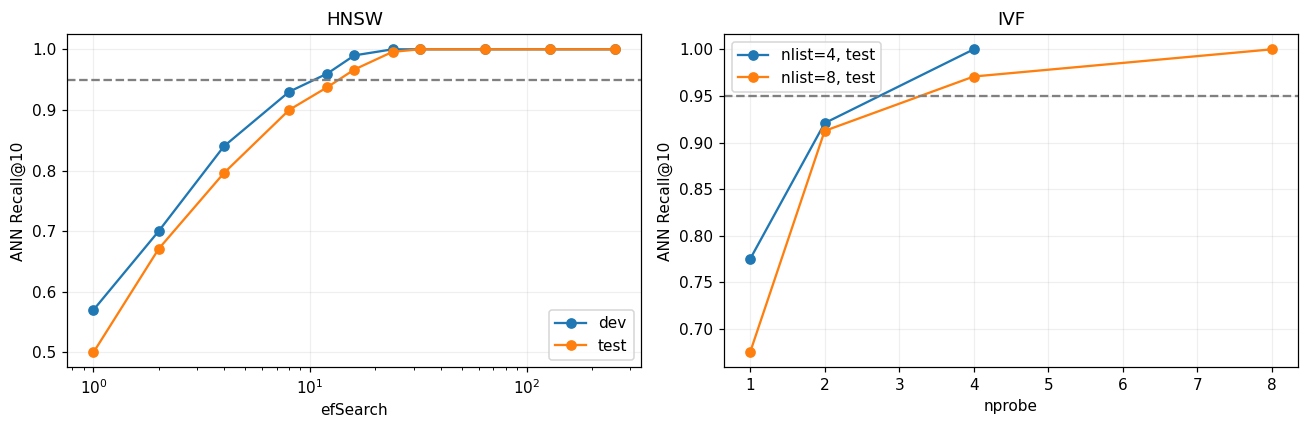

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
h = main_results[main_results["family"] == "HNSW"]
for split in ["dev", "test"]:
    axes[0].plot(h["efSearch"], h[f"{split}_recall"], marker="o", label=split)
axes[0].axhline(TARGET_RECALL, color="gray", linestyle="--")
axes[0].set(xscale="log", xlabel="efSearch", ylabel="ANN Recall@10", title="HNSW")
for nlist in NLIST_VALUES:
    frame = main_results[main_results["nlist"] == nlist]
    axes[1].plot(frame["nprobe"], frame["test_recall"], marker="o", label=f"nlist={nlist}, test")
axes[1].axhline(TARGET_RECALL, color="gray", linestyle="--")
axes[1].set(xlabel="nprobe", ylabel="ANN Recall@10", title="IVF")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "recall_parameters.png", bbox_inches="tight")
plt.show()

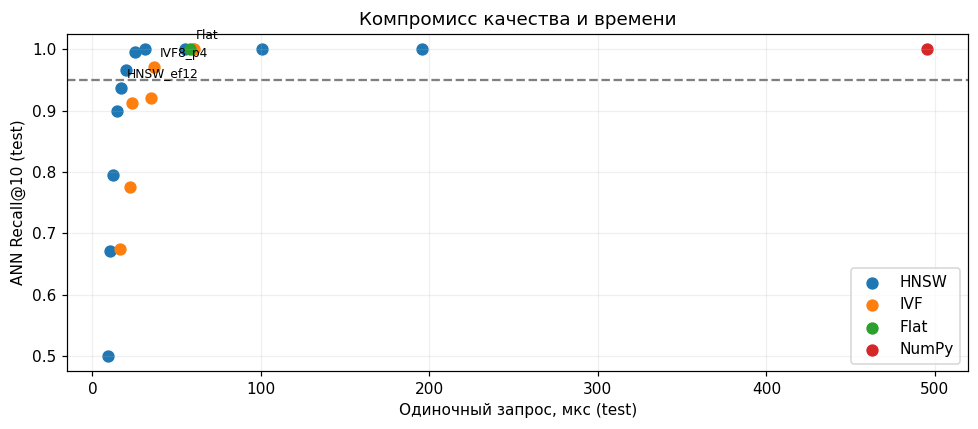

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for family in ["HNSW", "IVF", "Flat", "NumPy"]:
    frame = main_results[main_results["family"] == family]
    ax.scatter(frame["test_us"], frame["test_recall"], label=family, s=50)
for _, row in selected.iterrows():
    ax.annotate(row["label"], (row["test_us"], row["test_recall"]),
                xytext=(4, 7), textcoords="offset points", fontsize=8)
ax.axhline(TARGET_RECALL, color="gray", linestyle="--")
ax.set(xlabel="Одиночный запрос, мкс (test)", ylabel="ANN Recall@10 (test)",
       title="Компромисс качества и времени")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "quality_latency.png", bbox_inches="tight")
plt.show()

На test точный FlatIP обрабатывает одиночный запрос за
**57,8 мкс**, выбранный HNSW — за **16,8 мкс**,
IVF — за **36,4 мкс**. Ускорение HNSW составляет
**3,43 раза**, но его test Recall ниже целевого порога.
Сравнение скорости всегда нужно читать вместе с качеством.

NumPy и FlatIP возвращают одинаковые соседние чанки, хотя их время отличается.
Это показывает, почему нельзя приписывать всё ускорение относительно простой
матричной реализации только алгоритму ANN. Пакетный режим также отличается от
одиночных запросов; для окупаемости ниже используем именно одиночный режим.

### Связность графа и стоимость построения


In [ ]:
ablation_rows, ablation_trials = [], []
for m in M_VALUES:
    for construction in CONSTRUCTION_VALUES:
        params = {"M": m, "efConstruction": construction}
        index, info, trials = build_index("HNSW", X, params)
        index.hnsw.efSearch = int(best_hnsw["efSearch"])
        _, found = index.search(Q, K)
        ablation_rows.append({**params, **info, **quality_summary(exact_ids, found)})
        ablation_trials.append(trials.assign(M=m, efConstruction=construction))
ablation = pd.DataFrame(ablation_rows)
display(ablation[["M", "efConstruction", "build_s", "index_MiB", "dev_recall", "test_recall"]].round(4))

,M,efConstruction,build_s,index_MiB,dev_recall,test_recall
0,8,40,0.0185,0.6632,0.94,0.9208
1,8,100,0.0360,0.6632,0.94,0.9250
2,16,40,0.0163,0.6895,0.97,0.9375
3,16,100,0.0331,0.6895,0.96,0.9375
4,32,40,0.0237,0.7420,0.98,0.9875
5,32,100,0.0347,0.7420,0.96,0.9667


При efSearch=12 увеличение M с 8 до 32
повышает размер графа: индекс растёт с **0,663**
до **0,742 МиБ**. Качество меняется,
но не строго монотонно для каждой пары параметров. Например, более высокий
efConstruction не во всех строках улучшил Recall на этих запросах.

Дополнительные связи и более тщательная сборка требуют памяти и времени;
их полезность нужно измерять. Эта таблица — отдельный анализ чувствительности,
а не повод заново выбрать параметры по уже просмотренному test.

## 6. Качество по разметке релевантности


In [ ]:
relevance = pd.concat([relevance_scores(ids).assign(label=label)
                       for label, ids in rankings.items()], ignore_index=True)
relevance_summary = relevance.groupby(["label", "split"])[
    ["DocRecall", "MRR", "Hit@1", "unique_documents"]].mean().reset_index()
display(relevance_summary[(relevance_summary["split"] == "test") &
                          relevance_summary["label"].isin(selected_labels)].round(4))

,label,split,DocRecall,MRR,Hit@1,unique_documents
1,Flat,test,0.8542,0.6518,0.5417,7.7917
5,HNSW_ef12,test,0.8542,0.6528,0.5417,7.6250
35,IVF8_p4,test,0.8542,0.6518,0.5417,7.7500


По исходной разметке все три выбранных варианта имеют
test DocRecall **0,854**, Hit@1 — **0,542**.
У Flat MRR равен **0,6518**, у HNSW — **0,6528**,
у IVF — **0,6518**. Небольшое различие MRR не доказывает улучшения
смыслового поиска: ниже видно случайное изменение ранга из-за пропуска соседа.

Точные 10 чанков представляют в среднем **7,79 документа**.
Ошибки ANN могут затронуть другие чанки того же документа и не изменить DocRecall.
Эти значения нельзя напрямую сравнивать с прошлым Recall@5: тогда оценивались
5 документов после агрегации всей коллекции, здесь бюджет — 10 найденных чанков.

In [ ]:
def case_metrics(position):
    labels = ["Flat", "HNSW_ef1", best_hnsw["label"], "IVF8_p1", best_ivf["label"]]
    query_id = queries.iloc[position]["query_id"]
    rows = []
    for label in dict.fromkeys(labels):
        found = rankings[label][position]
        metrics = relevance[(relevance["label"] == label) & (relevance["query_id"] == query_id)].iloc[0]
        recall = neighbor_recall(exact_ids[position:position + 1], found[None, :])[0]
        rows.append({"index": label, "ANN Recall@10": recall,
                     "DocRecall": metrics["DocRecall"], "MRR": metrics["MRR"],
                     "Документов в выдаче": len(document_ranking(found))})
    return pd.DataFrame(rows)

In [ ]:
case_candidates = queries.copy()
for label in ["Flat", "HNSW_ef1", best_hnsw["label"], "IVF8_p1", best_ivf["label"]]:
    case_candidates[label + "_ann"] = neighbor_recall(exact_ids, rankings[label])
    frame = relevance[relevance["label"] == label].set_index("query_id")
    case_candidates[label + "_doc"] = queries["query_id"].map(frame["DocRecall"])
    case_candidates[label + "_mrr"] = queries["query_id"].map(frame["MRR"])
case_candidates["hnsw_gain"] = (case_candidates[best_hnsw["label"] + "_ann"] -
                                  case_candidates["HNSW_ef1_ann"])
case_candidates["ivf_gain"] = (case_candidates[best_ivf["label"] + "_doc"] -
                                 case_candidates["IVF8_p1_doc"])
case_candidates["ann_mrr_gain"] = (case_candidates[best_hnsw["label"] + "_mrr"] -
                                     case_candidates["Flat_mrr"])
case_candidates = case_candidates[TEST]

In [ ]:
case_positions = []
for column, ascending in [("ivf_gain", False), ("hnsw_gain", False),
                          ("Flat_mrr", True), ("ann_mrr_gain", False)]:
    candidates = case_candidates.drop(index=case_positions).sort_values(column, ascending=ascending)
    case_positions.append(int(candidates.index[0]))

def show_case(position):
    query = queries.iloc[position]
    print(query["query_id"], "—", query["query"])
    print("Релевантные документы:", ", ".join(sorted(gold[query["query_id"]])))
    display(case_metrics(position))
    ranked = {label: pd.Series(document_ranking(rankings[label][position]))
              for label in selected_labels}
    table = pd.DataFrame(ranked).fillna("—")
    table.index = np.arange(1, len(table) + 1)
    display(table.rename_axis("Ранг документа"))
    display(qrels[qrels["query_id"] == query["query_id"]][["doc_id", "reason", "evidence"]])

In [ ]:
show_case(case_positions[0])

Q03 — Implement setup and cleanup around a with block using a generator instead of writing a class.
Релевантные документы: contextlib.contextmanager


,index,ANN Recall@10,DocRecall,MRR,Документов в выдаче
0,Flat,1.0,1.0,1.0,8
1,HNSW_ef1,0.5,1.0,1.0,7
2,HNSW_ef12,0.8,1.0,1.0,7
3,IVF8_p1,0.4,0.0,0.0,9
4,IVF8_p4,1.0,1.0,1.0,8


,Flat,HNSW_ef12,IVF8_p4
Ранг документа,,,
1,contextlib.contextmanager,contextlib.contextmanager,contextlib.contextmanager
2,contextlib.aclosing,contextlib.aclosing,contextlib.aclosing
3,itertools.dropwhile,contextlib.closing,itertools.dropwhile
4,itertools.takewhile,itertools.chain.from_iterable,itertools.takewhile
5,contextlib.closing,functools.singledispatch,contextlib.closing
6,itertools.chain.from_iterable,itertools.accumulate,itertools.chain.from_iterable
7,functools.singledispatch,contextlib.ExitStack,functools.singledispatch
8,itertools.accumulate,—,itertools.accumulate


,doc_id,reason,evidence
15,contextlib.contextmanager,Декоратор создаёт менеджер контекста из генератора с yield.,This function is a decorator that can be used to define a factory function for wi...


Для `with`-блока на основе генератора нужен `contextlib.contextmanager`.
IVF с nprobe=1 пропустил релевантный документ: DocRecall упал с 1 до 0.
После расширения поиска он снова найден на первом месте. Это ошибка выбора
кандидатов индексом, а не отсутствие подходящего эмбеддинга: Flat уже находил ответ.

У HNSW выдача чанков также отличается от точной, но нужный документ остаётся
первым. Поэтому низкий ANN Recall не обязан означать такой же спад DocRecall.

In [ ]:
show_case(case_positions[1])

Q07 — Several streams should behave like one long stream, one after the other, without creating a big intermediate list.
Релевантные документы: itertools.chain, itertools.chain.from_iterable


,index,ANN Recall@10,DocRecall,MRR,Документов в выдаче
0,Flat,1.0,0.5,0.25,8
1,HNSW_ef1,0.0,0.0,0.00,8
2,HNSW_ef12,1.0,0.5,0.25,8
3,IVF8_p1,0.8,0.5,0.25,9
4,IVF8_p4,1.0,0.5,0.25,8


,Flat,HNSW_ef12,IVF8_p4
Ранг документа,,,
1,collections.deque,collections.deque,collections.deque
2,itertools.takewhile,itertools.takewhile,itertools.takewhile
3,itertools.tee,itertools.tee,itertools.tee
4,itertools.chain,itertools.chain,itertools.chain
5,concurrent.futures.Executor.map,concurrent.futures.Executor.map,concurrent.futures.Executor.map
6,itertools.repeat,itertools.repeat,itertools.repeat
7,collections.ChainMap,collections.ChainMap,collections.ChainMap
8,itertools.count,itertools.count,itertools.count


,doc_id,reason,evidence
19,itertools.chain,Оба API последовательно обходят входные итераторы без материализации общего списка.,Make an iterator that returns elements from the first iterable until it is exhaus...
20,itertools.chain.from_iterable,Оба API последовательно обходят входные итераторы без материализации общего списка.,Alternate constructor for chain() . Gets chained inputs from a single iterable ar...


Запрос требует лениво соединить потоки; релевантны `itertools.chain`
и `chain.from_iterable`. HNSW с efSearch=1 не нашёл ни одного чанка точной десятки
и потерял релевантный ответ. Настроенный HNSW восстановил точный набор соседей.

Однако даже Flat возвращает только один из двух размеченных документов,
и он стоит лишь на четвёртом месте. Здесь есть два источника ошибок:
недостаточная ширина ANN и ограничение самого смыслового ранжирования.

In [ ]:
show_case(case_positions[2])

Q02 — The same calculation keeps running for arguments I have already seen. How do I reuse earlier answers?
Релевантные документы: functools.cache, functools.lru_cache


,index,ANN Recall@10,DocRecall,MRR,Документов в выдаче
0,Flat,1.0,0.0,0.0,8
1,HNSW_ef1,0.1,0.0,0.0,9
2,HNSW_ef12,0.9,0.0,0.0,7
3,IVF8_p1,0.6,0.0,0.0,7
4,IVF8_p4,1.0,0.0,0.0,8


,Flat,HNSW_ef12,IVF8_p4
Ранг документа,,,
1,itertools.accumulate,itertools.accumulate,itertools.accumulate
2,re.sub,re.sub,re.sub
3,itertools.product,itertools.product,itertools.product
4,itertools.islice,itertools.islice,itertools.islice
5,functools.partial,functools.partial,functools.partial
6,functools.reduce,functools.reduce,functools.reduce
7,re.split,re.split,re.split
8,re.Match.group,—,re.Match.group


,doc_id,reason,evidence
13,functools.cache,Оба декоратора сохраняют результаты вызова по аргументам; cached_property работае...,Simple lightweight unbounded function cache. Sometimes called “memoize” .
14,functools.lru_cache,Оба декоратора сохраняют результаты вызова по аргументам; cached_property работае...,Decorator to wrap a function with a memoizing callable that saves up to the maxsi...


Повторное использование результатов одинаковых вызовов описывают
`functools.cache` и `functools.lru_cache`. Ни один из них не попал даже в точные
top-10 чанков. Среди первых результатов оказались `itertools.accumulate`, `re.sub`
и `itertools.product`, которые не решают задачу запоминания результатов вызова.

Это ограничение эмбеддингов, представления текста и ранжирования в данном корпусе.
Повышение efSearch или просмотр всех IVF-списков не исправит точный порядок.
Имеет смысл отдельно проверять другую модель, гибридный поиск или переранжирование.

In [ ]:
show_case(case_positions[3])

Q18 — Handle background jobs in the order they finish, not the order they were submitted.
Релевантные документы: concurrent.futures.as_completed


,index,ANN Recall@10,DocRecall,MRR,Документов в выдаче
0,Flat,1.0,1.0,0.142857,9
1,HNSW_ef1,0.1,0.0,0.000000,8
2,HNSW_ef12,0.8,1.0,0.166667,9
3,IVF8_p1,0.6,1.0,0.200000,8
4,IVF8_p4,1.0,1.0,0.142857,9


,Flat,HNSW_ef12,IVF8_p4
Ранг документа,,,
1,subprocess.Popen,subprocess.Popen,subprocess.Popen
2,subprocess.CompletedProcess,subprocess.CompletedProcess,subprocess.CompletedProcess
3,concurrent.futures.Executor.shutdown,concurrent.futures.Executor.shutdown,concurrent.futures.Executor.shutdown
4,concurrent.futures.Future.set_running_or_notify_cancel,concurrent.futures.Future.set_running_or_notify_cancel,concurrent.futures.Future.set_running_or_notify_cancel
5,contextlib.ExitStack.pop_all,contextlib.ExitStack.pop_all,contextlib.ExitStack.pop_all
6,contextlib.ExitStack.push,concurrent.futures.as_completed,contextlib.ExitStack.push
7,concurrent.futures.as_completed,subprocess.check_call,concurrent.futures.as_completed
8,functools.total_ordering,subprocess.check_output,functools.total_ordering
9,subprocess.check_call,collections.OrderedDict.move_to_end,subprocess.check_call


,doc_id,reason,evidence
32,concurrent.futures.as_completed,Итератор выдаёт Future по мере завершения; Executor.map сохраняет порядок входа.,Returns an iterator over the Future instances (possibly created by different Exec...


Нужен `concurrent.futures.as_completed`: результаты выдаются по мере
завершения, а не в порядке отправки заданий. В точной выдаче документ занимает
7-е место, в настроенном HNSW — 6-е. MRR вырос с 1/7 до 1/6, хотя ANN Recall@10
составил только 0,8.

Индекс случайно пропустил стоящий выше нерелевантный документ. Это не улучшение
понимания запроса и не надёжный способ переранжирования. При слишком узком HNSW
тот же релевантный документ вообще теряется.

## 7. Стоимость построения и окупаемость


Для Q запросов сравниваем `B + Q · t`, где B — медианное время построения,
а t — время одиночного запроса. Если ANN быстрее FlatIP, то
`Q* = ceil(max(0, B_ANN − B_Flat) / (t_Flat − t_ANN))`.
Если поиск ANN не быстрее, при большей стоимости построения окупаемости нет.
Это расчёт для последовательных запросов к уже загруженному индексу, без обновлений.


In [ ]:
def break_even(build_s, search_us, flat_build_s, flat_search_us):
    saved_us = flat_search_us - search_us
    if saved_us <= 0:
        return np.inf
    return math.ceil(max(0, build_s - flat_build_s) * 1_000_000 / saved_us)


def cost_table(frame):
    baseline = frame[frame["family"] == "Flat"].iloc[0]
    result = frame.copy()
    result["speedup"] = baseline["test_us"] / result["test_us"]
    result["break_even_queries"] = [
        break_even(row["build_s"], row["test_us"], baseline["build_s"], baseline["test_us"])
        if row["family"] != "Flat" else 0 for _, row in result.iterrows()]
    return result

In [ ]:
main_costs = cost_table(selected)
main_costs[["label", "build_s", "test_us", "speedup", "break_even_queries"]].round(4)

,label,build_s,test_us,speedup,break_even_queries
0,Flat,0.0001,57.8090,1.0000,0
1,HNSW_ef12,0.0332,16.8455,3.4317,807
2,IVF8_p4,0.0038,36.3749,1.5893,174


На реальном корпусе математическая точка окупаемости
HNSW — около **807 запросов**, IVF —
около **174**. Это стоимость однократной
сборки плюс последовательный поиск; поиск HNSW при этом не прошёл test-порог качества.

Экономия составляет лишь десятки микросекунд на запрос. Для небольшой коллекции
простота и отсутствие потерь у Flat могут быть важнее такого выигрыша.
При частых перестроениях B приходится платить снова. Порог изменится и при другой
нагрузке, числе потоков или времени обработки запроса, поэтому это оценка данного запуска.

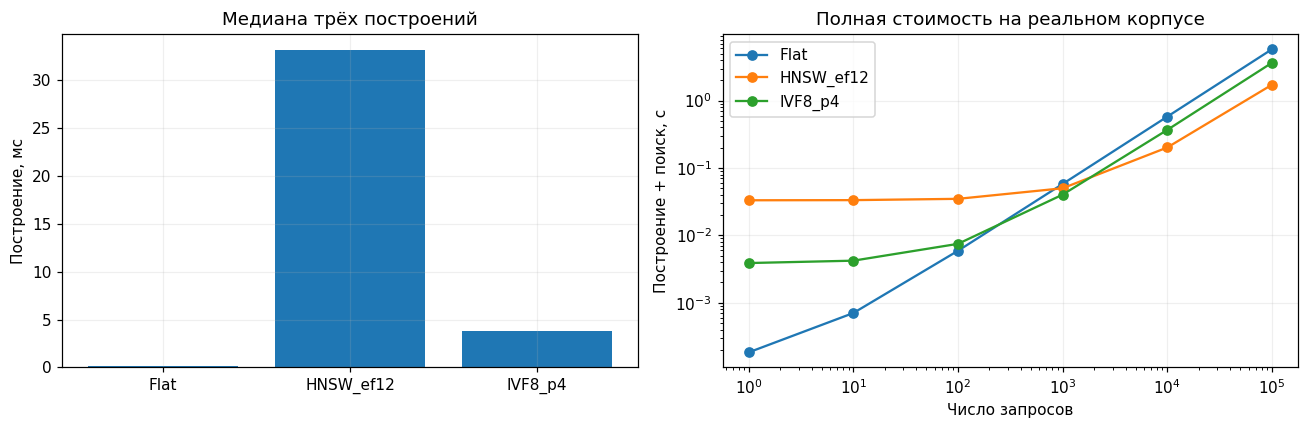

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(selected["label"], selected["build_s"] * 1000)
axes[0].set(ylabel="Построение, мс", title="Медиана трёх построений")
for _, row in selected.iterrows():
    total = row["build_s"] + QUERY_COUNTS * row["test_us"] / 1_000_000
    axes[1].plot(QUERY_COUNTS, total, marker="o", label=row["label"])
axes[1].set(xscale="log", yscale="log", xlabel="Число запросов",
            ylabel="Построение + поиск, с", title="Полная стоимость на реальном корпусе")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / "build_and_amortization.png", bbox_inches="tight")
plt.show()

## 8. Размер коллекции


Сначала используем вложенные случайные подвыборки **100, 250 и 430 настоящих
чанков**. Их состав задаётся до поиска одним seed; запросы остаются прежними,
а точные соседи пересчитываются отдельно для каждой коллекции.

Исходный корпус слишком мал, чтобы исследовать десятки тысяч векторов. Поэтому
добавляем отдельный **синтетический нагрузочный эксперимент**: выбираем исходные
векторы с возвращением, прибавляем гауссов шум с ожидаемой нормой около 0,20 и
снова нормализуем. Размеры — 2 000, 10 000 и 50 000. Это не новые документы и
не эмбеддинги новых текстов; разметку релевантности к ним применять нельзя.
Шум устраняет точные копии, но сохраняет искусственную кластерную структуру.

Наибольшая матрица занимает около 73 МиБ. Полный перебор выполним для **всех**
коллекций; сокращать эталон не требуется. Для каждого размера подбираем efSearch
и nprobe только на dev. Дополнительно переносим efSearch с исходных 430 чанков
без настройки, чтобы проверить устойчивость старой конфигурации.


In [ ]:
rng = np.random.default_rng(SEED)
real_order = rng.permutation(len(X))
extra_count = max(STRESS_SIZES) - len(X)
parents = rng.integers(0, len(X), extra_count)
noise = rng.normal(0, NOISE_NORM / np.sqrt(X.shape[1]), (extra_count, X.shape[1])).astype("float32")
synthetic = X[parents] + noise
faiss.normalize_L2(synthetic)
stress_vectors = np.ascontiguousarray(np.vstack([X, synthetic]))
del noise, synthetic
print("Максимальная коллекция:", stress_vectors.shape)
print("Объём векторов, МиБ:", round(stress_vectors.nbytes / 2**20, 2))

Максимальная коллекция: (50000, 384)
Объём векторов, МиБ: 73.24


In [ ]:
def scale_nlist(size):
    desired = 2 ** int(np.floor(np.log2(np.sqrt(size))))
    return min(desired, 2 ** int(np.floor(np.log2(max(1, size // 39)))))


def tune_scale(index, family, reference):
    values = SCALE_EF_VALUES if family == "HNSW" else sorted(
        set([p for p in [1, 2, 4, 8, 16, 32, 64, 128] if p <= index.nlist] + [index.nlist]))
    rows = []
    for value in values:
        if family == "HNSW":
            index.hnsw.efSearch = value
        else:
            index.nprobe = value
        _, found = index.search(Q, K)
        recall = neighbor_recall(reference, found)
        rows.append({"parameter": value, "dev_recall": recall[DEV].mean(),
                     "test_recall": recall[TEST].mean()})
    accepted = [row for row in rows if row["dev_recall"] >= TARGET_RECALL]
    return (accepted[0] if accepted else rows[-1]), rows

In [ ]:
scale_rows, scale_curves, scale_latencies, scale_build_trials = [], [], [], []


def measure_scale(index, family, size, kind, reference, build, parameters, policy="tuned"):
    _, found = index.search(Q, K)
    samples, batches = collect_search_times(index, Q)
    row = {"N": size, "collection": kind, "family": family, "policy": policy,
           **parameters, **build, **quality_summary(reference, found),
           **summarize_times(samples, batches)}
    scale_rows.append(row)
    scale_latencies.append(samples.assign(N=size, family=family, policy=policy))

In [ ]:
def run_scale_ann(family, vectors, kind, reference):
    size = len(vectors)
    params = ({"M": HNSW_M, "efConstruction": EF_CONSTRUCTION} if family == "HNSW"
              else {"nlist": scale_nlist(size)})
    index, build, trials = build_index(family, vectors, params)
    scale_build_trials.append(trials.assign(N=size, family=family))
    choice, curve = tune_scale(index, family, reference)
    scale_curves.extend({"N": size, "family": family, **row} for row in curve)
    key = "efSearch" if family == "HNSW" else "nprobe"
    if family == "HNSW":
        index.hnsw.efSearch = choice["parameter"]
    else:
        index.nprobe = choice["parameter"]
    measure_scale(index, family, size, kind, reference, build, {**params, key: choice["parameter"]})
    if family == "HNSW":
        index.hnsw.efSearch = int(best_hnsw["efSearch"])
        measure_scale(index, family, size, kind, reference, build,
                      {**params, key: int(best_hnsw["efSearch"])}, policy="fixed")

In [ ]:
for size in REAL_SIZES + STRESS_SIZES:
    kind = "real" if size in REAL_SIZES else "synthetic"
    vectors = (X if size == len(X) else np.ascontiguousarray(X[real_order[:size]])) if kind == "real" else stress_vectors[:size]
    baseline, build, trials = build_index("Flat", vectors, {})
    _, reference = baseline.search(Q, K)
    scores_check, ids_check = numpy_search(vectors, Q[:3])
    assert np.all(neighbor_recall(reference[:3], ids_check) == 1)
    scale_build_trials.append(trials.assign(N=size, family="Flat"))
    measure_scale(baseline, "Flat", size, kind, reference, build, {})
    for family in ["HNSW", "IVF"]:
        run_scale_ann(family, vectors, kind, reference)
    print(f"Готово: {kind}, N={size:,}", flush=True)
    del baseline
    gc.collect()

Готово: real, N=100


Готово: real, N=250


Готово: real, N=430


Готово: synthetic, N=2,000


Готово: synthetic, N=10,000


Готово: synthetic, N=50,000


In [ ]:
scaling = pd.DataFrame(scale_rows)
scaling_costs = pd.concat([cost_table(frame) for _, frame in scaling.groupby("N")], ignore_index=True)
scaling_costs["quality_ok"] = ((scaling_costs["dev_recall"] >= TARGET_RECALL) &
                               (scaling_costs["test_recall"] >= TARGET_RECALL))
display(scaling_costs[scaling_costs["policy"] == "tuned"][[
    "N", "collection", "family", "efSearch", "nprobe", "test_recall",
    "test_us", "build_s", "index_MiB", "break_even_queries", "quality_ok"]].round(4))

,N,collection,family,efSearch,nprobe,test_recall,test_us,build_s,index_MiB,break_even_queries,quality_ok
0,100,real,Flat,NaN,NaN,1.0000,17.9619,0.0001,0.1465,0.0,True
1,100,real,HNSW,12.0,NaN,0.9667,11.9860,0.0037,0.1606,604.0,True
3,100,real,IVF,NaN,2.0,1.0000,20.3263,0.0010,0.1503,inf,True
4,250,real,Flat,NaN,NaN,1.0000,35.9220,0.0001,0.3663,0.0,True
5,250,real,HNSW,8.0,NaN,0.9042,13.9513,0.0160,0.4008,724.0,False
7,250,real,IVF,NaN,2.0,0.9125,25.0834,0.0021,0.3741,190.0,False
8,430,real,Flat,NaN,NaN,1.0000,57.4514,0.0001,0.6299,0.0,True
9,430,real,HNSW,12.0,NaN,0.9375,16.6858,0.0332,0.6895,812.0,False
11,430,real,IVF,NaN,4.0,0.9708,36.6909,0.0038,0.6451,180.0,True
12,2000,synthetic,Flat,NaN,NaN,1.0000,236.8020,0.0002,2.9297,0.0,True


Время Flat растёт с **18,0 мкс**
на 100 настоящих векторах до **5,73 мс** на 50 000
искусственных векторах. Рост близок к линейному по объёму просматриваемой коллекции.
При 100 векторах IVF с просмотром всех списков медленнее Flat и не окупается.

На 50 000 векторах IVF с nlist=128, nprobe=4
имеет test Recall@10 **0,996** и время
**0,317 мс** — примерно
**18,1 раза быстрее** Flat.
Построение занимает **5,77 с**, окупаемость — около
**1 066 запросов**. Индекс занимает
**73,81 МиБ**.

Столбец `quality_ok` требует прохождения среднего порога и на dev, и на test.
Малый расчётный порог окупаемости строки с `False` не делает такую конфигурацию
приемлемой. `tuned` означает выполнение процедуры настройки; если сетка исчерпана,
показывается крайнее значение, а не выдуманное достижение порога.

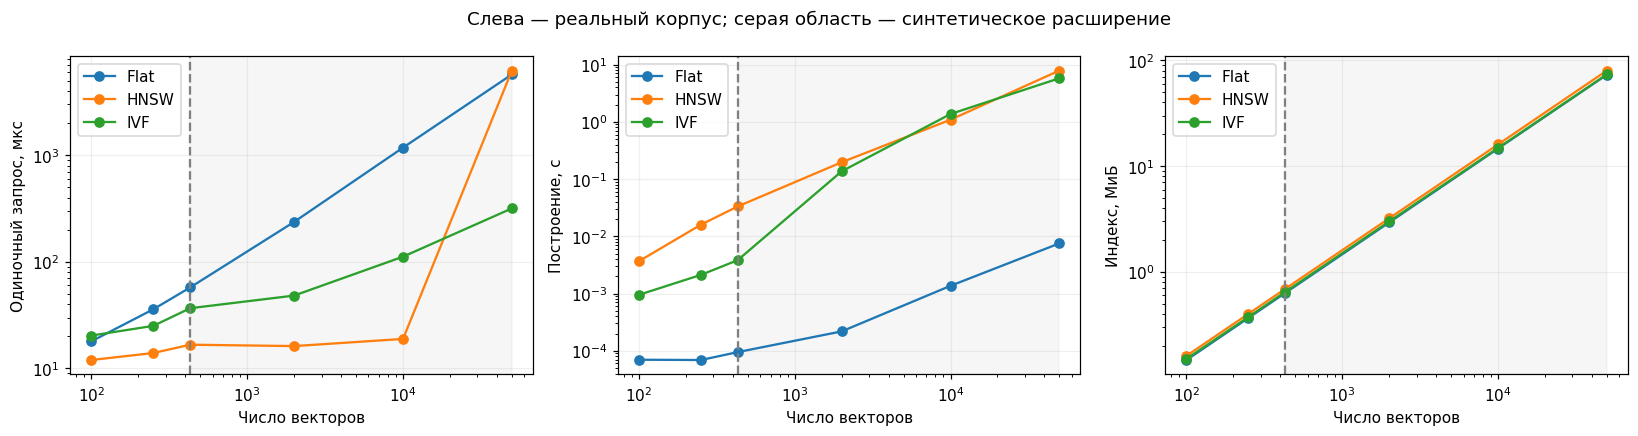

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for family in ["Flat", "HNSW", "IVF"]:
    frame = scaling[(scaling["family"] == family) & (scaling["policy"] == "tuned")]
    for ax, column in zip(axes, ["test_us", "build_s", "index_MiB"]):
        ax.plot(frame["N"], frame[column], marker="o", label=family)
for ax, ylabel in zip(axes, ["Одиночный запрос, мкс", "Построение, с", "Индекс, МиБ"]):
    ax.set(xscale="log", yscale="log", xlabel="Число векторов", ylabel=ylabel)
    ax.axvline(len(X), color="gray", linestyle="--")
    ax.axvspan(len(X) + 1, max(STRESS_SIZES), color="gray", alpha=0.07)
    ax.legend()
fig.suptitle("Слева — реальный корпус; серая область — синтетическое расширение")
fig.tight_layout()
fig.savefig(FIGURES / "scaling_costs.png", bbox_inches="tight")
plt.show()

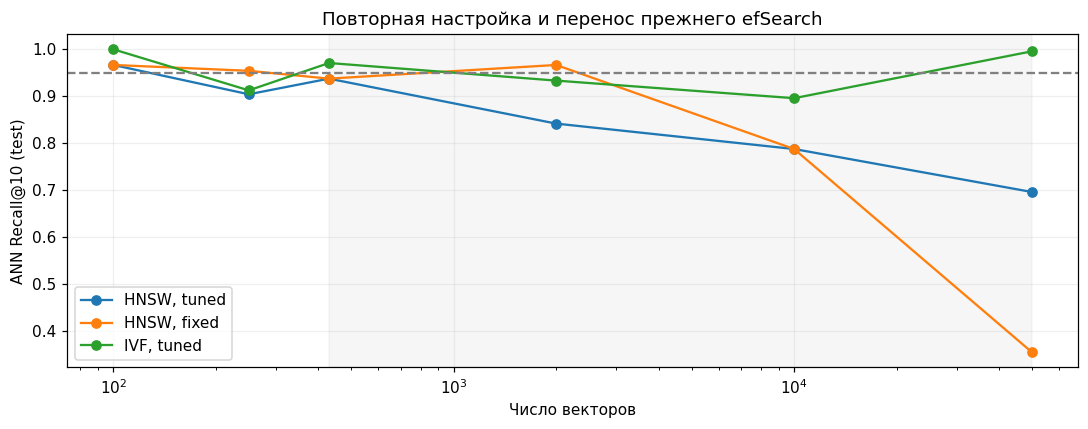

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for family, policy in [("HNSW", "tuned"), ("HNSW", "fixed"), ("IVF", "tuned")]:
    frame = scaling[(scaling["family"] == family) & (scaling["policy"] == policy)]
    ax.plot(frame["N"], frame["test_recall"], marker="o", label=f"{family}, {policy}")
ax.axhline(TARGET_RECALL, color="gray", linestyle="--")
ax.axvspan(len(X) + 1, max(STRESS_SIZES), color="gray", alpha=0.07)
ax.set(xscale="log", xlabel="Число векторов", ylabel="ANN Recall@10 (test)",
       title="Повторная настройка и перенос прежнего efSearch")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "scaling_recall.png", bbox_inches="tight")
plt.show()

Прямой перенос efSearch=12 на
50 000 векторов дал test Recall@10 только **0,354**.
Даже расширение до **2048** дало dev
**0,730** и test **0,696**:
в исследованной сетке целевой уровень не достигнут. При этом поиск уже занимает
**6,23 мс**, то есть не быстрее Flat.

Следовательно, увеличение efSearch не заменяет качественного построения графа.
Синтетические векторы образуют очень плотные группы вокруг исходных 430 точек;
результат относится к этой искусственной геометрии и M=16, efConstruction=100.
Для другого распределения нужно заново проверять связность, M, efConstruction
и порядок вставки. Это не доказательство непригодности HNSW для больших коллекций.

Качество на 2 000 и 10 000 векторах также показывает разрыв между dev и test.
Десяти запросов мало для уверенной настройки; минимум по dev нельзя выдавать
за гарантированную полноту на всех будущих запросах.

### Почему увеличение efSearch перестало помогать


In [ ]:
diagnostic_index = make_index("HNSW", X.shape[1],
                              {"M": HNSW_M, "efConstruction": EF_CONSTRUCTION})
diagnostic_index.add(stress_vectors)
assert diagnostic_index.ntotal == len(stress_vectors)
assert np.allclose(diagnostic_index.reconstruct(12_345), stress_vectors[12_345])
graph_offsets = faiss.vector_to_array(diagnostic_index.hnsw.offsets)
graph_links = faiss.vector_to_array(diagnostic_index.hnsw.neighbors)

In [ ]:
def reachable_vertices(offsets, links, entry):
    seen, pending = set(), [entry]
    while pending:
        vertex = pending.pop()
        if vertex in seen:
            continue
        seen.add(vertex)
        neighbors = links[int(offsets[vertex]):int(offsets[vertex + 1])]
        pending.extend(int(node) for node in neighbors if node >= 0 and int(node) not in seen)
    return len(seen)

In [ ]:
reachable = reachable_vertices(graph_offsets, graph_links, diagnostic_index.hnsw.entry_point)
graph_diagnostic = {"N": len(stress_vectors), "M": HNSW_M,
                    "efConstruction": EF_CONSTRUCTION, "reachable_all_levels": reachable,
                    "unreachable": len(stress_vectors) - reachable,
                    "reachable_fraction": reachable / len(stress_vectors)}
display(pd.Series(graph_diagnostic))
(RESULTS / "graph_diagnostic.json").write_text(json.dumps(graph_diagnostic, indent=2))
del diagnostic_index, graph_offsets, graph_links

N                       50000.00000
M                          16.00000
efConstruction            100.00000
reachable_all_levels    32709.00000
unreachable             17291.00000
reachable_fraction          0.65418
dtype: float64

Проверка воспроизвела тот же граф из тех же
векторов и с теми же настройками. Все 50 000 векторов присутствуют в индексе,
а выборочная реконструкция совпала с входом. Однако из точки входа достижимы
лишь **32 709 вершин**
(65,42%), даже если разрешить обход
по всем рёбрам всех уровней без ограничений efSearch.

Обычный поиск из этой точки входа не может посетить
оставшиеся вершины — **17 291**. Это достаточное объяснение того, почему
расширение поиска не восстанавливает полную выдачу в данном эксперименте.
Обход для диагностики шире реального HNSW-поиска: достижимость ещё не гарантирует,
что конкретный поиск посетит вершину. Проверять другие M и efConstruction и
перестраивать граф здесь осмысленнее, чем бесконечно повышать efSearch.

## 9. Добавление и изменение векторов


FlatIP принимает новые векторы через `add`. Удаление из обычного Flat сдвигает
последующие номера, поэтому для стабильных внешних ID удобен `IndexIDMap2`:
изменённый документ можно удалить и добавить заново под тем же ID.

HNSW поддерживает добавление, но в выбранной реализации FAISS нет обычного
удаления вершины с сохранением корректного графа. Для изменённых документов
можно хранить новые версии, фильтровать устаревшие ID и периодически перестраивать
индекс. Такая фильтрация потребует дополнительного бюджета кандидатов.

IVFFlat после обучения принимает новые векторы в существующие списки. `DirectMap`
обеспечивает обращение по ID и обновление. `Array` подходит последовательным ID;
для произвольных ID и удаления применяют `Hashtable` и совместимый селектор.
При изменении распределения данных старые центроиды могут ухудшить поиск:
понадобятся новое обучение и перенос коллекции в новый индекс.
[Операции с индексами](https://github.com/facebookresearch/faiss/wiki/Special-operations-on-indexes),
[ограничения HNSW](https://github.com/facebookresearch/faiss/wiki/Faiss-indexes).


In [ ]:
stable_flat = faiss.IndexIDMap2(faiss.IndexFlatIP(X.shape[1]))
stable_flat.add_with_ids(X[:20], np.arange(20, dtype="int64"))
stable_flat.add_with_ids(X[20:21], np.array([1000], dtype="int64"))
removed = stable_flat.remove_ids(np.array([0], dtype="int64"))
stable_flat.add_with_ids(X[1:2], np.array([0], dtype="int64"))
assert removed == 1 and stable_flat.ntotal == 21
assert np.allclose(stable_flat.reconstruct(0), X[1])
print("Flat + IDMap2: добавление и замена под прежним ID проверены.")

Flat + IDMap2: добавление и замена под прежним ID проверены.


In [ ]:
ivf_update = faiss.clone_index(ivf_indexes[int(best_ivf["nlist"])])
ivf_update.make_direct_map()
ivf_update.add(X[:1])
ivf_update.update_vectors(np.array([0], dtype="int64"), X[1:2])
assert ivf_update.ntotal == len(X) + 1
assert np.allclose(ivf_update.reconstruct(0), X[1])
print("IVFFlat + DirectMap.Array: добавление и update_vectors проверены.")

IVFFlat + DirectMap.Array: добавление и update_vectors проверены.


In [ ]:
hnsw_update = faiss.clone_index(hnsw)
hnsw_update.add(X[:1])
assert hnsw_update.ntotal == len(X) + 1
try:
    hnsw_update.remove_ids(np.array([0], dtype="int64"))
    hnsw_removal = "Операция поддерживается этой версией"
except RuntimeError:
    hnsw_removal = "remove_ids не поддерживается в IndexHNSWFlat"
print("HNSW: добавление проверено;", hnsw_removal)

HNSW: добавление проверено; remove_ids не поддерживается в IndexHNSWFlat


Проверки выполнены на копиях индексов и не меняют результаты сравнения. При реальном
редактировании документа сначала нужно заново разбить его на чанки и вычислить
эмбеддинги затронутых частей. Стабильный `doc_id`, версии и атомарная замена индекса
нужны, чтобы пользователи не видели одновременно старые и новые инструкции.
Стоимость регулярных обновлений увеличивает найденные выше сроки окупаемости.


## 10. Рекомендация для поисковой системы


**Для текущих 430 чанков я выберу FAISS FlatIP.**
Он хранит около 0,63 МиБ и отвечает за
57,8 мкс без ошибок приближения. Для учебной коллекции,
небольшого потока запросов и частых изменений это простая и достаточная конфигурация.
Главное ограничение сейчас — смысловые ошибки BGE на отдельных запросах;
ускорение индекса их не устраняет.

Если реальная коллекция вырастет до десятков тысяч векторов и будет обслуживать
тысячи запросов между перестроениями, **IVFFlat с nlist=128, nprobe=4** — кандидат
для следующего испытания. На синтетических 50 000 векторов он сочетал Recall@10
0,996, задержку 0,317 мс и
построение за 5,77 с. При 10 000 последовательных запросов
расчётная общая стоимость составляет
8,94 с против
57,30 с у Flat.
До внедрения нужно повторить проверку на настоящем расширенном корпусе и новых запросах.

HNSW требует отдельной перенастройки графа: выбранный минимум efSearch на малой
выборке не прошёл test-порог, а на большом искусственном наборе увеличение ширины
поиска не восстановило качество. Высокую скорость без требуемой полноты я не считаю
достаточным основанием для выбора.

Эмбеддинги определяют геометрию поиска: какие тексты оказываются близкими.
Индекс определяет, насколько быстро и точно мы найдём соседей в этой геометрии.
Рост efSearch или nprobe сокращает ошибки ANN, но не исправляет неверное смысловое
сопоставление, уже присутствующее в точном поиске.

Смена модели эмбеддингов может изменить качество даже при том же типе индекса.
Нужно заново закодировать документы и запросы одной моделью, перестроить индекс и
повторить настройку. Смешивать в одном индексе старое и новое пространство нельзя,
даже если размерность обоих равна 384. Аналогично, другое разбиение на чанки меняет
число векторов, их содержание, дублирование документов в top-10 и стоимость поиска.


## 11. Ограничения исследования


- Реальная коллекция мала и ограничена 12 модулями Python 3.13. Англоязычные
  запросы не проверяют русский, смешанный язык и другие технические области.
- Всего 10 dev- и 24 test-запроса. Bootstrap отражает вариацию этих запросов,
  но не исправляет неполноту разметки. Независимая ручная проверка отмечена отдельно.
- Большие коллекции искусственно расширены из 430 векторов. Они полезны для
  измерения нагрузки, но не доказывают качество поиска на 50 000 настоящих документов.
- Проверена одна модель и одна стратегия чанков, выбранные на прошлом этапе.
  Иная модель, размерность, перекрытие и распределение тем могут изменить все результаты.
- Измерения сделаны в Docker на CPU, в один поток, после прогрева. Это не оценка
  холодного старта, конкурентной нагрузки, GPU, диска, сети или полного времени ответа.
- Время на небольших массивах измеряется в микросекундах и подвержено шуму.
  Порог окупаемости — оценка для данного запуска, а не универсальное число.
- Исследована ограниченная сетка параметров и один порядок добавления. Минимальное
  efSearch означает минимум среди проверенных значений для данного графа и dev-набора.
- Размер файла индекса не равен пиковой RAM. Не исследованы сжатие PQ,
  распределённые индексы, шардирование и устойчивость к длительному потоку обновлений.


## 12. Сохранение результатов


In [ ]:
tables = {"main_metrics": main_results, "selected": selected, "main_costs": main_costs,
          "main_build_trials": build_trials, "main_latency": pd.concat(latency_frames),
          "main_batch_latency": pd.DataFrame(batch_rows), "graph_ablation": ablation,
          "graph_build_trials": pd.concat(ablation_trials), "relevance_per_query": relevance,
          "relevance_summary": relevance_summary, "scaling": scaling_costs,
          "scaling_tuning": pd.DataFrame(scale_curves),
          "scaling_latency": pd.concat(scale_latencies),
          "scaling_build_trials": pd.concat(scale_build_trials)}
for name, frame in tables.items():
    frame.to_csv(RESULTS / f"{name}.csv", index=False)
np.savez_compressed(RESULTS / "rankings.npz", **rankings)

In [ ]:
case_records = []
for position in case_positions:
    query = queries.iloc[position]
    case_records.append({"query_id": query["query_id"], "query": query["query"],
                         "relevant_docs": sorted(gold[query["query_id"]]),
                         "comparison": case_metrics(position).to_dict("records")})
(RESULTS / "cases.json").write_text(json.dumps(case_records, ensure_ascii=False, indent=2))
(RESULTS / "chunk_ids.json").write_text(json.dumps(chunks["chunk_id"].tolist()))
(RESULTS / "query_ids.json").write_text(json.dumps(queries["query_id"].tolist()))

238

In [ ]:
hnsw.hnsw.efSearch = int(best_hnsw["efSearch"])
ivf_selected = ivf_indexes[int(best_ivf["nlist"])]
ivf_selected.nprobe = int(best_ivf["nprobe"])
for name, index in [("Flat", flat), ("HNSW", hnsw), ("IVF", ivf_selected)]:
    faiss.write_index(index, str(INDEXES / f"{name}.faiss"))
    loaded = faiss.read_index(str(INDEXES / f"{name}.faiss"))
    assert np.array_equal(loaded.search(Q, K)[1], index.search(Q, K)[1])
print("Индексы сохранены; выдача после загрузки совпала.")

Индексы сохранены; выдача после загрузки совпала.


In [ ]:
experiment = {"seed": SEED, "k": K, "target_dev_recall": TARGET_RECALL,
              "model": MODEL, "model_revision": revisions["BGE"], "chunk_strategy": "fixed",
              "selected_hnsw": best_hnsw["label"], "selected_ivf": best_ivf["label"],
              "build_repeats": BUILD_REPEATS, "search_rounds": SEARCH_ROUNDS,
              "warmup_rounds": WARMUP_ROUNDS, "training_limit": TRAIN_LIMIT,
              "ef_values": EF_VALUES, "scale_ef_values": SCALE_EF_VALUES, "nlist_values": NLIST_VALUES,
              "nprobe_values": NPROBE_VALUES, "real_sizes": REAL_SIZES,
              "stress_sizes": STRESS_SIZES, "synthetic_noise_norm": NOISE_NORM,
              "environment": environment, "inputs": manifest}
(RESULTS / "experiment.json").write_text(json.dumps(experiment, ensure_ascii=False, indent=2))
print("Таблицы, замеры, выдача, графики и параметры сохранены в", RESULTS.name)

Таблицы, замеры, выдача, графики и параметры сохранены в faiss_results
